In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import os
from pathlib import Path
from collections import Counter
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import TimeSeriesSplit
import seaborn as sns

#### DESCARGO INFORMACIÓN

In [5]:
# Obtener la carpeta donde se está ejecutando el notebook
actualDir = Path(os.getcwd())

# Construir las rutas asumiendo que la carpeta 'data' está junto al notebook
resultsDir = actualDir / 'data' / 'results.csv'
rankingsDir = actualDir / 'data' / 'elo_ratings_wc2026.csv'

# Carga de datos
results = pd.read_csv(resultsDir)
rankings = pd.read_csv(rankingsDir)

# Añado la columna year a results para poder hacer el merge
results['year'] = pd.to_datetime(results['date']).dt.year

# Me quedo con los datos a partir del 2020 para evitar problemas con datos antiguos
results = results[results['year'] >= 2020]
# Nos quedamos con los que han sido antes del 4-07-2026 para evitar problemas con los partidos de la fase de clasificación
results = results[results['date'] < '2026-07-04']

print("Datos cargados correctamente en el Notebook")

Datos cargados correctamente en el Notebook


#### LIMPIEZA DE DATOS

In [6]:
# 1. DETERMINAR GANADOR REAL (Simple: solo goles)
def determinar_ganador(row):
    if row['home_score'] > row['away_score']: 
        return 'Home'
    elif row['away_score'] > row['home_score']: 
        return 'Away'
    else:
        return 'Draw'

results['real_winner'] = results.apply(determinar_ganador, axis=1)

# 3. INTEGRAR RANKINGS (ELO)
rankings_clean = rankings[['year', 'country', 'rating']]

# Unimos local
df = results.merge(
    rankings_clean.rename(columns={'country': 'home_team', 'rating': 'home_rating'}), 
    on=['year', 'home_team'], 
    how='left'
)

# Unimos visitante
df = df.merge(
    rankings_clean.rename(columns={'country': 'away_team', 'rating': 'away_rating'}), 
    on=['year', 'away_team'], 
    how='left'
)

# Añado la diferencia de rating como una nueva característica
df['rating_diff'] = df['home_rating'] - df['away_rating']

# 4. LIMPIEZA FINAL Y PESOS
df['home_rating'] = df['home_rating'].fillna(0)
df['away_rating'] = df['away_rating'].fillna(0)

# Escala los pesos para que estén entre 0.1 y 1.0
df['weight'] = (df['year'] - df['year'].min() + 1)
df['weight'] = df['weight'] / df['weight'].max()

print("Dimensiones del DataFrame:", df.shape)

Dimensiones del DataFrame: (6645, 15)


In [7]:
df.dropna(subset=['home_rating', 'away_rating', "rating_diff"], inplace=True)

In [8]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,real_winner,home_rating,away_rating,rating_diff,weight
7,2020-09-03,Germany,Spain,1.0,1.0,UEFA Nations League,Stuttgart,Germany,False,2020,Draw,1955.0,2049.0,-94.0,0.142857
19,2020-09-04,Norway,Austria,1.0,2.0,UEFA Nations League,Oslo,Norway,False,2020,Away,1763.0,1786.0,-23.0,0.142857
27,2020-09-05,Portugal,Croatia,4.0,1.0,UEFA Nations League,Porto,Portugal,False,2020,Home,2038.0,1860.0,178.0,0.142857
28,2020-09-05,Sweden,France,0.0,1.0,UEFA Nations League,Stockholm,Sweden,False,2020,Away,1820.0,2091.0,-271.0,0.142857
35,2020-09-06,Switzerland,Germany,1.0,1.0,UEFA Nations League,Basel,Switzerland,False,2020,Draw,1870.0,1955.0,-85.0,0.142857


In [9]:
# Diferencio si el partido es amistoso o de competición
# Borra las filas donde la columna 'tournament' es NaN
df = df.dropna(subset=['tournament'])
df['tournament_type'] = df['tournament'].apply(
    lambda x: 'Friendly' if 'Friendly' in x else 'Competition'
)

if 'neutral' in df.columns:
    df['neutral'] = df['neutral'].astype(str)  # Convertimos a string para evitar problemas con NaN

# One-hot encoding para las variables categóricas
categorical_cols = [col for col in ['tournament_type', 'neutral'] if col in df.columns]
if categorical_cols:
    df = pd.get_dummies(
        df,
        columns=categorical_cols,
        prefix=categorical_cols,
        dtype=int
    )


In [10]:
def map_target(row):
    if row['real_winner'] == 'Home':
        return 2  # Gana local
    if row['real_winner'] == 'Away':
        return 0  # Gana visita
    return 1  # Empate


df['target'] = df.apply(map_target, axis=1)


In [11]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,year,real_winner,home_rating,away_rating,rating_diff,weight,tournament_type_Competition,tournament_type_Friendly,neutral_False,neutral_True,target
7,2020-09-03,Germany,Spain,1.0,1.0,UEFA Nations League,Stuttgart,Germany,2020,Draw,1955.0,2049.0,-94.0,0.142857,1,0,1,0,1
19,2020-09-04,Norway,Austria,1.0,2.0,UEFA Nations League,Oslo,Norway,2020,Away,1763.0,1786.0,-23.0,0.142857,1,0,1,0,0
27,2020-09-05,Portugal,Croatia,4.0,1.0,UEFA Nations League,Porto,Portugal,2020,Home,2038.0,1860.0,178.0,0.142857,1,0,1,0,2
28,2020-09-05,Sweden,France,0.0,1.0,UEFA Nations League,Stockholm,Sweden,2020,Away,1820.0,2091.0,-271.0,0.142857,1,0,1,0,0
35,2020-09-06,Switzerland,Germany,1.0,1.0,UEFA Nations League,Basel,Switzerland,2020,Draw,1870.0,1955.0,-85.0,0.142857,1,0,1,0,1


#### ENTRENAMIENTO

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05], # Mantén valores bajos para evitar sobreajuste
    'max_depth': [3, 4],           # 5 y 7 suelen causar overfitting en datos deportivos
    'subsample': [0.8],            # Ayuda a generalizar
    'reg_lambda': [1.0, 5.0],      # L2 regularization, fundamental para evitar probabilidades extremas
    'reg_alpha': [0.1, 1.0]        # L1 regularization
}

# 1. Definimos las features SIN el peso
one_hot_features = [
    col for col in df.columns
    if col.startswith('tournament_type_') or col.startswith('neutral_')
]
features = ['home_rating', 'away_rating', 'rating_diff'] + one_hot_features

# 2. Separamos X, y, y los pesos ANTES de dividir
X = df[features]
y = df['target']
weights = df['weight']

# 3. Dividimos usando los mismos índices para todo
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights, test_size=0.2, random_state=42, stratify=y
)

# 4. Definimos el modelo con random_state para reproducibilidad
# Parámetros elegidos:
# - eval_metric='mlogloss': métrica adecuada para clasificación multiclase
# - random_state=42: semilla para reproducibilidad de resultados
# - verbosity=0: evita mensajes excesivos durante el entrenamiento
xgb = XGBClassifier(eval_metric='mlogloss', random_state=42, verbosity=0)

# 5. Definimos la validación cruzada temporal (el test siempre es posterior al train)
# TimeSeriesSplit evita la fuga de datos temporal en series de tiempo
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=xgb, 
    param_grid=param_grid, 
    scoring='neg_log_loss',
    cv=tscv, 
    verbose=1, 
    n_jobs=-1
)

# 6. Ejecución: pasamos los pesos por separado
# w_train: pondera los partidos recientes más que los antiguos
grid_search.fit(X_train, y_train, sample_weight=w_train)

# 7. Resultados
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
print(f"Mejor score (neg_log_loss): {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Mejores parámetros encontrados: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'subsample': 0.8}
Mejor score (neg_log_loss): -0.7687


#### EVALUACIÓN

In [13]:
# Evaluación del modelo en el conjunto de prueba
y_pred = grid_search.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy en el conjunto de prueba: {accuracy:.4f}")


Accuracy en el conjunto de prueba: 0.7137


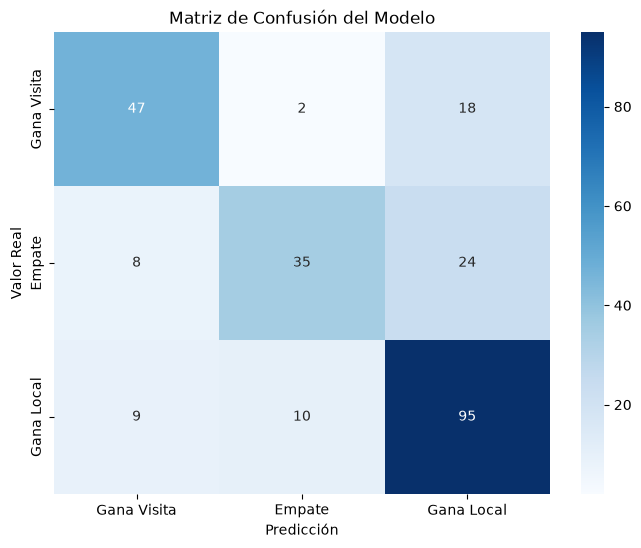

In [14]:


# 1. Calcular la matriz
conf_matrix = confusion_matrix(y_test, y_pred)

# 2. Configurar la visualización
plt.figure(figsize=(8, 6))

# 3. Crear el heatmap
# Etiquetas personalizadas según tu target (0=Visita, 1=Empate, 2=Local)
labels = ['Gana Visita', 'Empate', 'Gana Local']

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

# 4. Detalles estéticos
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión del Modelo')
plt.show()

In [15]:
# Ahora el reporte de clasificación
print(classification_report(y_test, y_pred, target_names=labels))


              precision    recall  f1-score   support

 Gana Visita       0.73      0.70      0.72        67
      Empate       0.74      0.52      0.61        67
  Gana Local       0.69      0.83      0.76       114

    accuracy                           0.71       248
   macro avg       0.72      0.69      0.70       248
weighted avg       0.72      0.71      0.71       248



In [ ]:
def obtener_rating(pais, anio):
    """
    Obtiene el rating ELO de un país para un año específico.
    
    Args:
        pais (str): Nombre del país
        anio (int): Año para el cual obtener el rating
        
    Returns:
        float: Rating ELO del país, o 0 si no hay datos disponibles
        
    Nota: Para 2026, usa el rating más reciente disponible en los datos
    """
    # Filtramos el dataframe de rankings por país y año
    res = rankings[(rankings['country'] == pais) & (rankings['year'] == anio)]
    
    if not res.empty:
        return res['rating'].values[0]
    else:
        # Si no hay datos para el año solicitado, intentamos con el más reciente
        res_reciente = rankings[rankings['country'] == pais].sort_values('year', ascending=False)
        if not res_reciente.empty:
            rating_usado = res_reciente['rating'].values[0]
            # Silenciosamente usamos el rating más reciente disponible
            return rating_usado
        else:
            # Si no hay ningún dato del país, retornamos 0
            return 0

#### PREDICCIÓN

In [ ]:
def construir_input_partido(team1, team2, neutral='True'):
    """
    Construye el input del modelo para predecir un partido.
    
    Args:
        team1 (str): Equipo local
        team2 (str): Equipo visitante
        neutral (str): 'True' si el campo es neutral, 'False' en caso contrario
        
    Returns:
        pd.DataFrame: DataFrame con features preparadas para el modelo
    """
    input_partido = pd.DataFrame({
        'home_rating': [obtener_rating(team1, 2026)],
        'away_rating': [obtener_rating(team2, 2026)],
        'rating_diff': [obtener_rating(team1, 2026) - obtener_rating(team2, 2026)],
        'tournament_type': ['Competition'],
        'neutral': [str(neutral)]
    })

    input_partido = pd.get_dummies(
        input_partido,
        columns=['tournament_type', 'neutral'],
        prefix=['tournament_type', 'neutral'],
        dtype=int
    )

    return input_partido.reindex(columns=features, fill_value=0)


def predecir_partido(team1, team2, imprimir_resultado=False):
    """
    Predice las probabilidades de un partido entre dos equipos.
    
    Utiliza el promedio de dos perspectivas:
    - Probabilidad de team1 como local vs team2 como visitante
    - Probabilidad de team2 como local vs team1 como visitante
    
    Args:
        team1 (str): Primer equipo
        team2 (str): Segundo equipo
        imprimir_resultado (bool): Si True, imprime las probabilidades
        
    Returns:
        tuple: (prob_team1, prob_empate, prob_team2)
    """
    input_partido = construir_input_partido(team1, team2, neutral='True')

    # Obtenemos las probabilidades (perspectiva 1: team1 como local)
    pred1 = grid_search.predict_proba(input_partido)
    
    input_partido = construir_input_partido(team2, team1, neutral='True')

    # Obtenemos las probabilidades (perspectiva 2: team2 como local)
    pred2 = grid_search.predict_proba(input_partido)

    # Combinamos las probabilidades de ambos escenarios (promediamos)
    prob_team1 = (pred1[0][2] + pred2[0][0]) / 2
    prob_empate = (pred1[0][1] + pred2[0][1]) / 2
    prob_team2 = (pred1[0][0] + pred2[0][2]) / 2

    if imprimir_resultado:
        print(f"Probabilidades para {team1} vs {team2}:")
        print(f"Victoria  {team1}: {prob_team1:.2%}")
        print(f"Empate: {prob_empate:.2%}")
        print(f"Victoria {team2}: {prob_team2:.2%}")


    # Devolver el ganador probable
    return prob_team1, prob_empate, prob_team2

In [18]:
predecir_partido('Spain', 'Portugal', imprimir_resultado=True)

Probabilidades para Spain vs Portugal:
Victoria  Spain: 49.84%
Empate: 42.58%
Victoria Portugal: 7.57%


(np.float32(0.4984494), np.float32(0.4258108), np.float32(0.07573977))

#### FUNCIÓN PREDICCIÓN

In [ ]:
def predecir_partido_prob(team1, team2, random_state=None):
    """
    Predice el ganador de un partido usando probabilidades del modelo.
    
    Args:
        team1 (str): Equipo local
        team2 (str): Equipo visitante
        random_state (int, optional): Seed para reproducibilidad
        
    Returns:
        str: Nombre del equipo ganador
        
    Nota: Ignora los empates y normaliza probabilidades solo entre victorias
    """
    # 1. Obtener los valores crudos (incluye probabilidad de empate)
    gana, empata, pierde = predecir_partido(team1, team2)
    
    # 2. Calcular probabilidades ignorando el empate
    suma_ganadores = gana + pierde
    
    probs = np.array([gana / suma_ganadores, pierde / suma_ganadores])
    
    # 3. NORMALIZACIÓN: asegura que las probabilidades sumen 1
    probs = probs / probs.sum()
    
    # 4. Elegir ganador con seed para reproducibilidad
    if random_state is not None:
        np.random.seed(random_state)
    ganador = np.random.choice([team1, team2], p=probs)
    return ganador


def predecir_torneo(equipos, random_state=None):
    """
    Predice el ganador del torneo usando enfrentamientos recursivos.
    
    Args:
        equipos (list): Lista de equipos en la ronda actual
        random_state (int, optional): Seed para reproducibilidad
        
    Returns:
        str: Nombre del equipo ganador del torneo
        
    Algoritmo: Enfrenta equipos de 2 en 2, recursivamente, hasta un ganador
    """
    # Caso base: si solo queda un equipo, es el ganador
    if len(equipos) == 1:
        return equipos[0]
    
    siguientes = []
    
    # Procesar la fase actual: enfrentamientos de dos en dos
    for i in range(0, len(equipos), 2):
        team1 = equipos[i]
        team2 = equipos[i + 1]
        
        # Obtenemos el ganador del partido
        ganador = predecir_partido_prob(team1, team2, random_state=random_state)
        siguientes.append(ganador)
        
        # Opcional: imprimir el partido para ver el progreso
        # print(f"Partido: {team1} vs {team2} -> Ganador: {ganador}")
    
    # Llamada recursiva para la siguiente fase
    return predecir_torneo(siguientes, random_state=random_state)

#### SIMULACIÓN DEL TORNEO DESDE OCTAVOS (1000 VECES)

In [ ]:
def simular_torneo_completo(lista_equipos, n_simulaciones, random_state=None):
    """
    Simula un torneo N veces y calcula probabilidades de ganar.
    
    Args:
        lista_equipos (list): Lista de equipos para simular
        n_simulaciones (int): Número de simulaciones a ejecutar
        random_state (int, optional): Seed para reproducibilidad
        
    Returns:
        dict: Diccionario con probabilidades de ganar para cada equipo
        
    Nota: Mayor n_simulaciones = resultados más estables pero más tiempo de cómputo
    """
    # 1. Inicializamos el contador con 0 para todos los equipos introducidos
    conteo = {equipo: 0 for equipo in lista_equipos}
    
    print(f"Iniciando {n_simulaciones} simulaciones para {len(lista_equipos)} equipos...")
    
    # 2. Ejecución de la simulación con seeds para reproducibilidad
    for sim in range(n_simulaciones):
        # Incrementamos el seed en cada simulación para variabilidad
        seed_actual = (random_state + sim) if random_state is not None else None
        ganador = predecir_torneo(lista_equipos, random_state=seed_actual) 
        if ganador in conteo:
            conteo[ganador] += 1
            
    # 3. Cálculo y ordenamiento
    resultados_ordenados = sorted(conteo.items(), key=lambda item: item[1], reverse=True)
    
    # 4. Formateo y visualización
    print(f"\n{'Equipo':15} | {'Probabilidad':>12}")
    print("-" * 30)
    for equipo, cantidad in resultados_ordenados:
        porcentaje = (cantidad / n_simulaciones) * 100
        print(f"{equipo:15} | {porcentaje:>10.2f}%")
        
    return {equipo: (cantidad / n_simulaciones) for equipo, cantidad in conteo.items()}

In [21]:
octavos = [
    'Canada', 'Morocco', 'Paraguay', 'France', 'United States', 'Belgium',
    'Portugal', 'Spain', 'Brazil', 'Norway', 'Mexico', 'England', 'Switzerland',
    'Colombia', 'Argentina', 'Egypt'
]

probabilidades = simular_torneo_completo(octavos, n_simulaciones=50)

Iniciando 50 simulaciones para 16 equipos...

Equipo          | Probabilidad
------------------------------
Argentina       |      42.00%
Spain           |      38.00%
France          |      14.00%
Portugal        |       2.00%
Brazil          |       2.00%
Colombia        |       2.00%
Canada          |       0.00%
Morocco         |       0.00%
Paraguay        |       0.00%
United States   |       0.00%
Belgium         |       0.00%
Norway          |       0.00%
Mexico          |       0.00%
England         |       0.00%
Switzerland     |       0.00%
Egypt           |       0.00%


#### ANÁLISIS DE CARACTERÍSTICAS DEL MODELO

In [ ]:
# Obtener importancia de características del mejor modelo
best_model = grid_search.best_estimator_
feature_importance = best_model.feature_importances_

# Crear DataFrame para visualizar
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Importancia de características en el modelo:")
print(importance_df.to_string(index=False))

# Visualizar
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.xlabel('Importancia')
plt.title('Top 10 Características Más Importantes')
plt.tight_layout()
plt.show()

#### REPRODUCIBILIDAD Y VALIDACIÓN

In [ ]:
# Simulaciones con reproducibilidad (random_state fijo)
print("=" * 50)
print("SIMULACIÓN CON REPRODUCIBILIDAD (random_state=42)")
print("=" * 50)
probabilidades_reproducibles = simular_torneo_completo(octavos, n_simulaciones=50, random_state=42)

print("\n" + "=" * 50)
print("Notas sobre reproducibilidad:")
print("=" * 50)
print("✓ XGBClassifier tiene random_state=42 fijo")
print("✓ train_test_split usa random_state=42")
print("✓ Las simulaciones usan random_state para control de aleatoriedad")
print("✓ Ejecutar nuevamente con random_state=42 debería dar los mismos resultados")
print("\nPara comparar con otra configuración, incrementar n_simulaciones")
print("y/o cambiar el random_state (ej: random_state=123)")
